# Projet Problème Inverse

**Master M2 MIASHS**  
**Auteurs:** Marilou Martin-Auber  -  Matthieu Vivier

## Objectif

Ce projet propose d'étudier l'article [The faster proximal algorithm, the better unfolded deep learning architecture ?](https://hal.science/hal-03621538v1/file/EUSIPCO_2022_final.pdf) et de répondre aux questions suivantes:
1. Quel est le problème inverse considéré, quel type de dégradation.
2. Décrire la méthode proposée pour résoudre ce problème.
3. Quelle est la nouveauté par rapport à l’état-de-l’art.
4. Comprendre les résultats obtenus et le lien avec état-de-l’art.
5. Reproduire partiellement les simulations de l’article à l’aide de DeepInverse.

## 1. Quel est le problème inverse considéré, quel type de dégradation.

L'étude s'est concentrée sur le débruitage d'image standard consistant à récupérer l'image standard à partir de sa version dégradée.

Le problème inverse est énoncé dans la partie II. UNFOLDED DEEP LEARNING ARCHITECTURE A. Image denoising and associated objective function.
Soit le débruitage d'image et fonction objectif associée. La formule de problème inverse considérée est :

$z = \bar{x} + n \in \mathbb{R}^N$, où
$n \sim \mathcal{N}(0, \delta^2 I_N)$ désigne un bruit blanc gaussien additif d'écart-type $\delta > 0$.

## 2. Décrire la méthode proposée pour résoudre ce problème.

Pour résoudre ce problèmes les chercheurs ont utilisé une méthode n'ayant pas encore été étudié. Ils ont donc étudié l'impact des schémas accélérés sur les performances d'apprentissage des réseaux de deep learning dépliée.
Ainsi ils étudient deux algorithmes de débruitage d'image ISTA et CP mais aussi leur versions accélérées FISTA et CP avec hypothèse de convexité forte.

Le but est de transformer chaque itération en couche du réseau de neurone afin que les paramètres sooient appris automatiquement. Cela permet d'utiliser le Deep Learning sans le désavantage de la "boite noire" où l'on ne comprends pas comment les paramètres ont été fixé.
Ainsi quatre réseaux sont obtenus puis vérifier si les paramètre accélerant la covergance des algorithme permettent d'accélerer également la convergance dans le réseau.


## 3. Quelle est la nouveauté par rapport à l’état-de-l’art.

La nouveauté par rapport à l'état de l'art (DnCNN) est le fait que, selon les auteurs du papier, lorsqu'on considère des architectures dépliées, l'impact des schémas accélérés sur les performances d'apprentissage n'a pas encore été étudié.

In [ ]:
pip install deepinv

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 850.4/850.4 kB 14.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 43.3 MB/s eta 0:00:00


In [ ]:
!pip install ptwt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.2/67.2 kB 2.5 MB/s eta 0:00:00


In [ ]:
import deepinv as dinv
import torch
import torch.nn.functional as F
from deepinv.optim import BaseOptim
from deepinv.optim.optim_iterators import CPIteration, fStep, gStep

device = "cuda" if torch.cuda.is_available() else "cpu"

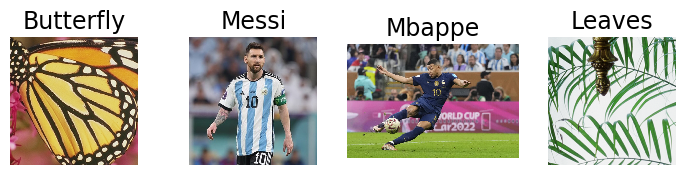

In [ ]:
# ============================================================
# 1. CHARGEMENT DES 4 IMAGES
# ============================================================
x1 = dinv.utils.load_example("butterfly.png", device=device)
x2 = dinv.utils.load_example("messi.jpg", device=device)
x3 = dinv.utils.load_example("mbappe.jpg", device=device)
x4 = dinv.utils.load_example("leaves.png", device=device)

# Afficher les images originales
dinv.utils.plot(
    [x1, x2, x3, x4],
    titles=["Butterfly", "Messi", "Mbappe", "Leaves"]
)

In [ ]:
# ============================================================
# 2. REDIMENSIONNER À LA MÊME TAILLE (obligatoire pour le batch)
# ============================================================
taille = (256, 256)
x1 = F.interpolate(x1, size=taille)
x2 = F.interpolate(x2, size=taille)
x3 = F.interpolate(x3, size=taille)
x4 = F.interpolate(x4, size=taille)

# Concatener en un seul batch
x_batch = torch.cat([x1, x2, x3, x4], dim=0)
print(f"Shape du batch : {x_batch.shape}")
# → torch.Size([4, 3, 256, 256])

Shape du batch : torch.Size([4, 3, 256, 256])


In [ ]:
# ============================================================
# 3. MODÈLE DE DÉGRADATION : bruit gaussien (δ=50 comme le papier)
# ============================================================
delta = 50 / 255.0
physics = dinv.physics.Denoising(
    noise_model=dinv.physics.GaussianNoise(sigma=delta),
    device=device
)
y_batch = physics(x_batch)  # bruiter les 4 images d'un coup

/usr/local/lib/python3.12/dist-packages/deepinv/physics/forward.py:68: UserWarning: Arguments {'device': 'cpu'} are passed to Denoising but are ignored.
  warnings.warn(


In [ ]:
# ============================================================
# 4. LES 4 RÉSEAUX DÉPLIÉS
# ============================================================
K_layers = 5  # nombre de couches

# Initialisation personnalisée pour CP (3 variables nécessaires)
def custom_init_CP(y, physics):
    x0 = physics.A_adjoint(y)   # variable primale x
    z0 = x0.clone()              # variable primale relaxée z
    u0 = torch.zeros_like(y)    # variable duale u
    return (x0, z0, u0)

def make_model_ISTA():
    return dinv.optim.optim_builder(
        iteration="PGD",
        prior=dinv.optim.prior.TVPrior(),
        data_fidelity=dinv.optim.data_fidelity.L2(),
        max_iter=K_layers,
        params_algo={"stepsize": [1.0] * K_layers, "lambda": 0.1}
    ).to(device)

def make_model_FISTA():
    return dinv.optim.optim_builder(
        iteration="FISTA",
        prior=dinv.optim.prior.TVPrior(),
        data_fidelity=dinv.optim.data_fidelity.L2(),
        max_iter=K_layers,
        params_algo={"stepsize": [1.0] * K_layers, "lambda": 0.1, "a": 2.1}
    ).to(device)

def make_model_CP(gamma=0.0):
    return dinv.optim.optim_builder(
        iteration="CP",
        prior=dinv.optim.prior.TVPrior(),
        data_fidelity=dinv.optim.data_fidelity.L2(),
        max_iter=K_layers,
        custom_init=custom_init_CP,
        params_algo={
            "stepsize": [1.0] * K_layers,       # pas primal τ
            "stepsize_dual": [1.0] * K_layers,   # pas dual σ ← correction ici
            "lambda": 0.1,
            "gamma": gamma,
        }
    ).to(device)

model_ISTA  = make_model_ISTA()           # Deep-ISTA-GD
model_FISTA = make_model_FISTA()          # Deep-FISTA-GD
model_CP    = make_model_CP(gamma=0.0)    # Deep-CP-GD
model_ScCP  = make_model_CP(gamma=1.0)    # Deep-ScCP-GD

In [ ]:
# ============================================================
# 5. DÉBRUITAGE ET CALCUL DU PSNR
# ============================================================
psnr = dinv.metric.PSNR()
noms_images = ["Butterfly", "Messi", "Mbappe", "Leaves"]
models = {
    "Deep-ISTA-GD":  model_ISTA,
    "Deep-FISTA-GD": model_FISTA,
    "Deep-CP-GD":    model_CP,
    "Deep-ScCP-GD":  model_ScCP,
}

resultats = {}
for nom_model, model in models.items():
    with torch.no_grad():
        x_hat = model(y_batch, physics)
    resultats[nom_model] = x_hat
    # PSNR par image
    for i, nom_img in enumerate(noms_images):
        score = psnr(x_hat[i:i+1], x_batch[i:i+1]).item()
        print(f"{nom_model} | {nom_img} → PSNR : {score:.2f} dB")
    print("---")

Deep-ISTA-GD | Butterfly → PSNR : 21.72 dB
Deep-ISTA-GD | Messi → PSNR : 22.37 dB
Deep-ISTA-GD | Mbappe → PSNR : 22.33 dB
Deep-ISTA-GD | Leaves → PSNR : 20.95 dB
---
Deep-FISTA-GD | Butterfly → PSNR : 21.72 dB
Deep-FISTA-GD | Messi → PSNR : 22.37 dB
Deep-FISTA-GD | Mbappe → PSNR : 22.33 dB
Deep-FISTA-GD | Leaves → PSNR : 20.95 dB
---
Deep-CP-GD | Butterfly → PSNR : 21.72 dB
Deep-CP-GD | Messi → PSNR : 22.37 dB
Deep-CP-GD | Mbappe → PSNR : 22.33 dB
Deep-CP-GD | Leaves → PSNR : 20.95 dB
---
Deep-ScCP-GD | Butterfly → PSNR : 21.72 dB
Deep-ScCP-GD | Messi → PSNR : 22.37 dB
Deep-ScCP-GD | Mbappe → PSNR : 22.33 dB
Deep-ScCP-GD | Leaves → PSNR : 20.95 dB
---


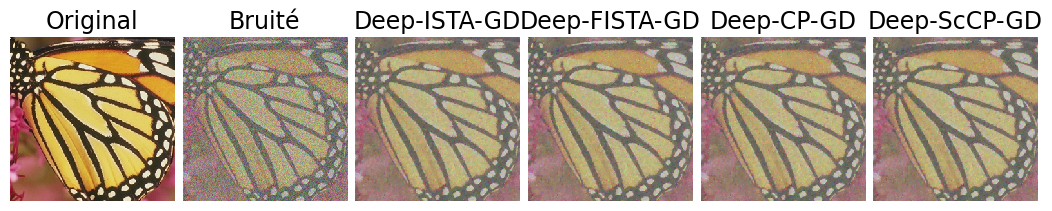

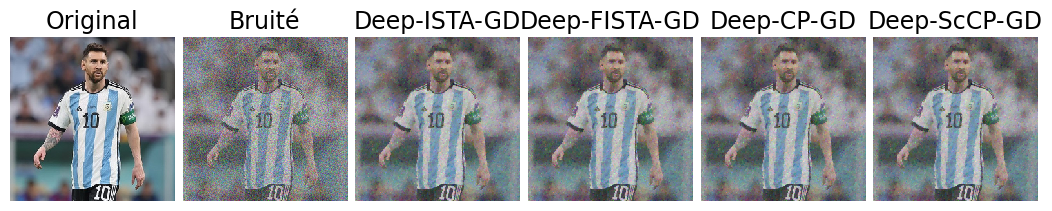

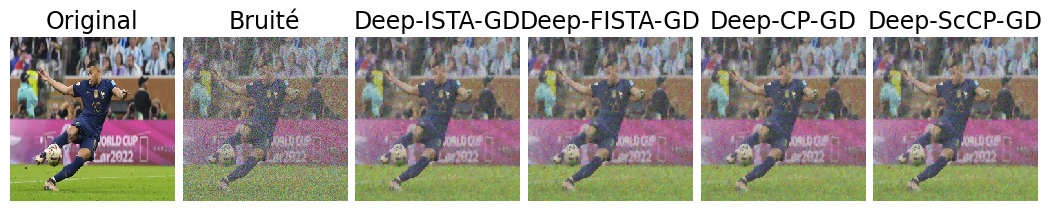

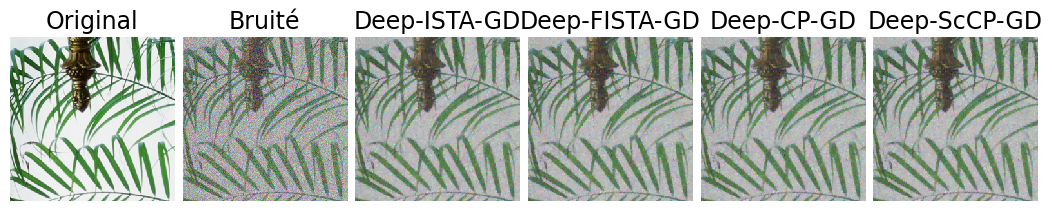

In [ ]:
# ============================================================
# 6. VISUALISATION PAR IMAGE
# ============================================================
for i, nom_img in enumerate(noms_images):
    dinv.utils.plot(
        [x_batch[i:i+1], y_batch[i:i+1]] +
        [resultats[nom][i:i+1] for nom in models],
        titles=["Original", "Bruité"] + list(models.keys())
    )


=== Butterfly ===
TV → PSNR : 18.09 dB
Deep-ISTA-GD → PSNR : 21.72 dB
Deep-FISTA-GD → PSNR : 21.72 dB
Deep-CP-GD → PSNR : 21.72 dB
Deep-ScCP-GD → PSNR : 21.72 dB


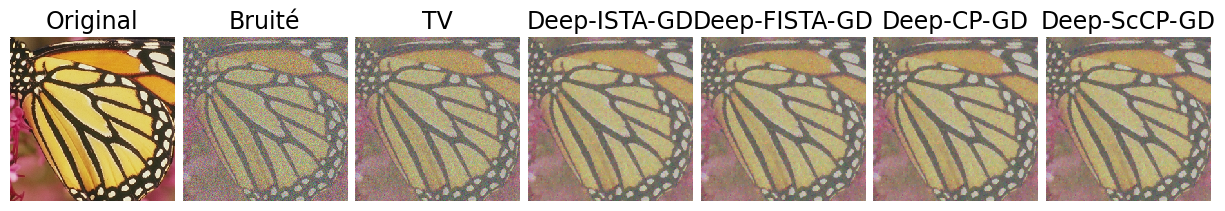


=== Messi ===
TV → PSNR : 18.24 dB
Deep-ISTA-GD → PSNR : 22.37 dB
Deep-FISTA-GD → PSNR : 22.37 dB
Deep-CP-GD → PSNR : 22.37 dB
Deep-ScCP-GD → PSNR : 22.37 dB


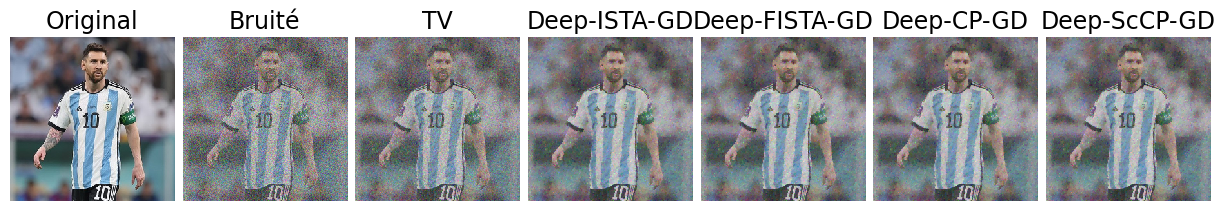


=== Mbappe ===
TV → PSNR : 18.26 dB
Deep-ISTA-GD → PSNR : 22.33 dB
Deep-FISTA-GD → PSNR : 22.33 dB
Deep-CP-GD → PSNR : 22.33 dB
Deep-ScCP-GD → PSNR : 22.33 dB


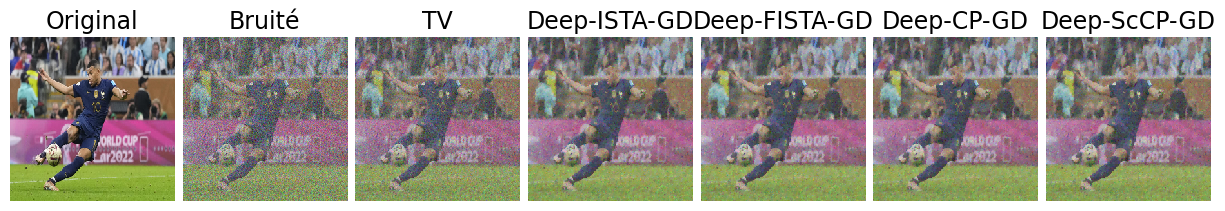


=== Leaves ===
TV → PSNR : 17.89 dB
Deep-ISTA-GD → PSNR : 20.95 dB
Deep-FISTA-GD → PSNR : 20.95 dB
Deep-CP-GD → PSNR : 20.95 dB
Deep-ScCP-GD → PSNR : 20.95 dB


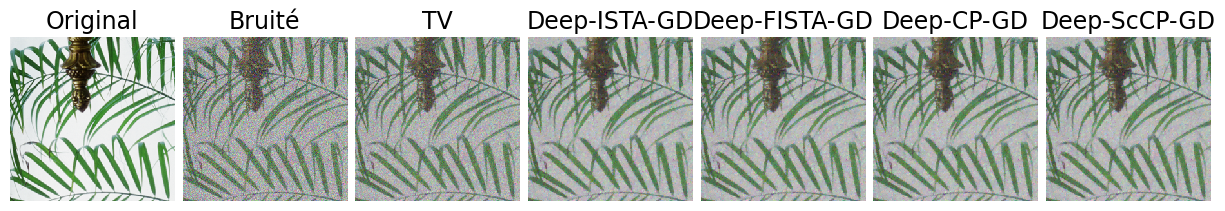

In [ ]:
# Modèle TV avec plus d'itérations
model_TV = dinv.optim.optim_builder(
    iteration="PGD",
    prior=dinv.optim.prior.TVPrior(),
    data_fidelity=dinv.optim.data_fidelity.L2(),
    max_iter=50,
    params_algo={"stepsize": 1.0, "lambda": 0.05}
).to(device)

models_comparaison = {
    "TV"           : model_TV,
    "Deep-ISTA-GD" : model_ISTA,
    "Deep-FISTA-GD": model_FISTA,
    "Deep-CP-GD"   : model_CP,
    "Deep-ScCP-GD" : model_ScCP,
}

psnr = dinv.metric.PSNR()

for i, nom_img in enumerate(noms_images):
    print(f"\n=== {nom_img} ===")
    resultats_comp = {}

    for nom_model, model in models_comparaison.items():
        with torch.no_grad():
            x_hat = model(y_batch[i:i+1], physics)
        score = psnr(x_hat, x_batch[i:i+1]).item()
        resultats_comp[nom_model] = (x_hat, score)
        print(f"{nom_model} → PSNR : {score:.2f} dB")

    # Visualisation
    dinv.utils.plot(
        [x_batch[i:i+1], y_batch[i:i+1]] +
        [resultats_comp[nom][0] for nom in models_comparaison],
        titles=["Original", "Bruité"] + list(models_comparaison.keys())
    )

Dans notre code, nous avons tenté de reproduire la structure des 4 réseaux proposés dans le papier, malheureusement sans la phase d'entraînement (faute de ressources computationnelles suffisantes). Les résultats que nous obtenons semblent néanmoins confirmer la tendance selon laquelle les réseaux dépliés surpassent TV, car déjà sans entraînement c'est le cas. Cela laisse supposer que l'entraînement accentuerait davantage cet écart.

